In [2]:
%load_ext autoreload
%autoreload 2 

In [3]:
from image import Image
from processor import PlaneMask, PlaneProjection
import os
import json
import matplotlib.pyplot as plt
from cells import RBCellMask, RBClusters, ClusterCountMask, extract_clusters
import numpy as np

In [ ]:
def slice_and_save(input_dir = 'data/raw', output_dir='data/sliced', width = 500):
    imgs_raw = Image.from_dir(input_dir)
    imgs_sliced = Image.slice_images(imgs_raw, width)
    Image.save_images(imgs_sliced, output_dir)

def save_clusters(imgs, random_n=None, output_dir = 'data/test'):
    if isinstance(imgs, Image):
        imgs = [imgs]
    if not random_n:
        imgs_chosen = imgs
    else:
        img_indices = np.random.choice(len(imgs), random_n, replace=False)
        imgs_chosen = [imgs[i] for i in img_indices]
    print(f"Images chosen: {[i.title for i in imgs_chosen]}")
    clusters = []
    labels = {}
    for img in imgs_chosen:
        c, l = extract_clusters(img)
        clusters += c
        labels |= l
    
    Image.save_images(clusters, output_dir)
    try:
        with open(f'{output_dir}/labels.json', 'r') as f:
            labels = json.load(f) | labels
    except Exception: pass
    with open(f'{output_dir}/labels.json', 'w') as f:
        json.dump(labels, f, indent=4)
        
# slice_and_save()
# slice_and_save(output_dir='data/sliced-1000', width = 1000)
imgs = Image.from_dir('data/sliced')
np.random.seed(42)
save_clusters(imgs, 5)
save_clusters(Image.from_path('data/sliced/I_37550251_2000_2000.jpg'))

print([i for i,img in enumerate(imgs) if img.title =='I_37550251_1500_2000'])

Images chosen: ['I_37550251_1500_2000', 'I_42757274_1500_500', 'I_42757274_1000_0', 'I_42757274_500_0', 'I_37550251_2000_1500']
Images chosen: ['I_37550251_2000_2000']
[13]


Selected index: 25. Selected image: I_42757274_0_0


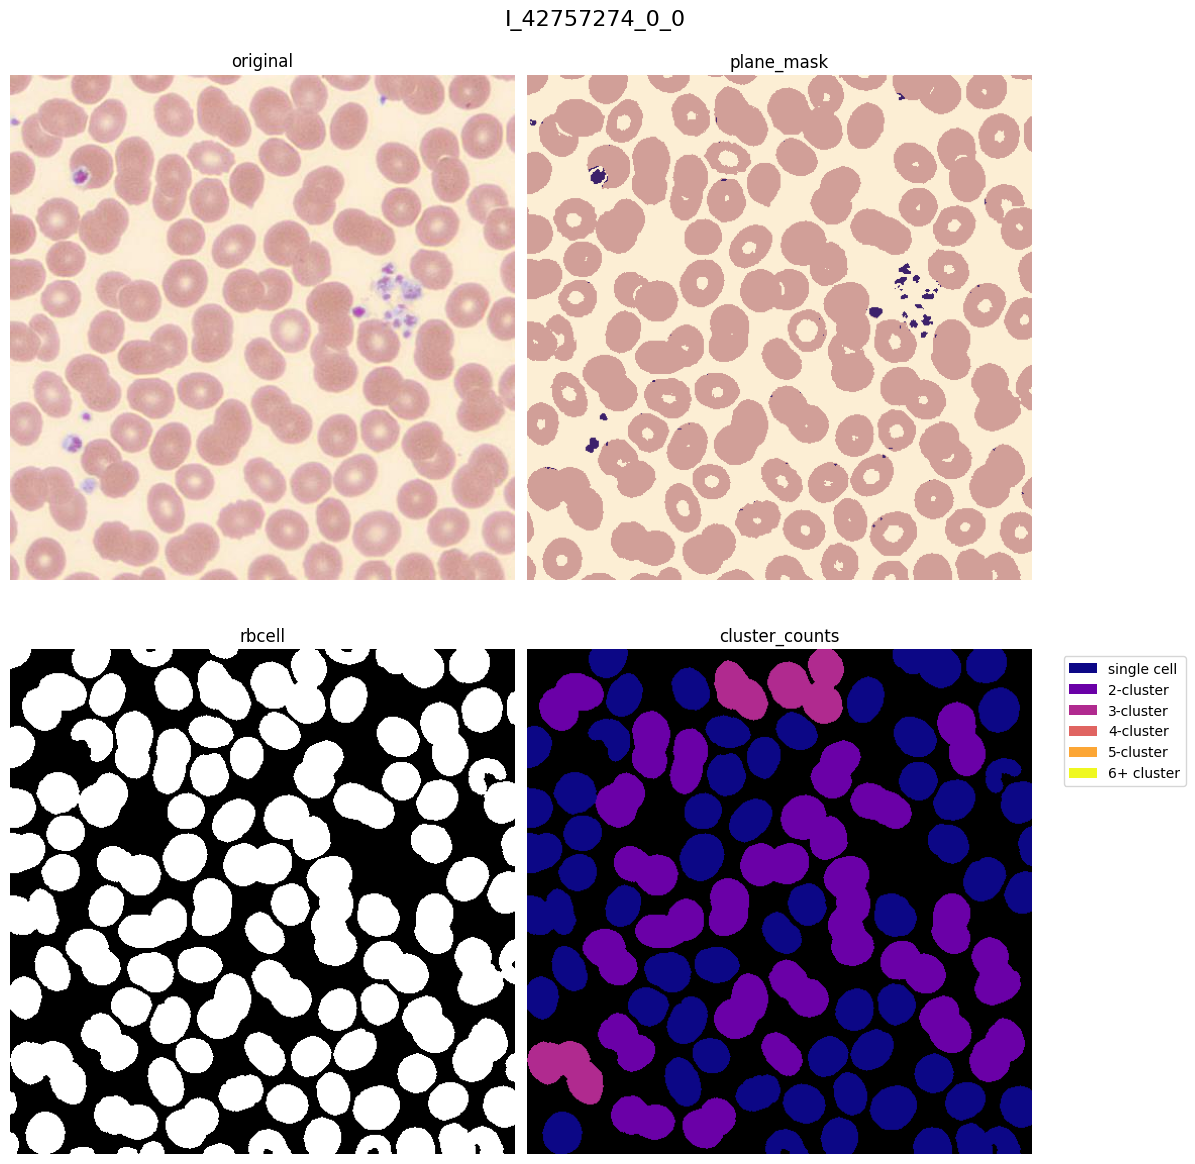

In [8]:
idx = np.random.randint(len(imgs))
# idx = 13

img = imgs[idx]
# img = Image.from_path('data/sliced/I_42757274_500_0.jpg')
print(f'Selected index: {idx}. Selected image: {img.title}')

mask_proj = PlaneProjection.from_json('configs/triangle.json')
img0_proj = mask_proj.process(img)
mask_plane = PlaneMask.from_json('configs/triangle.json')
img0_plane = mask_plane.process(img)
mask_rbc = RBCellMask.from_json('configs/triangle.json')
img0_rbc = mask_rbc.process(img)
mask_clusters = RBClusters.from_json('configs/triangle.json')
img0_clusters = mask_clusters.process(img)
mask_counts = ClusterCountMask.from_json('configs/triangle.json')
img_counts = mask_counts.process(img)
    

img.show_versions([
    'original', 
    # 'plane_projection', 
    'plane_mask', 
    'rbcell', 
    
    # 'rbclusters',
    'cluster_counts'
])

plt.show()


442
Total clusters: 442. Total cells: 429
Cluster sensitivity: 90.41%
Cluster precision: 92.96%
Cluster specificity: 98.60%
Cluster errors: MAE 0.05, MSE: 0.05


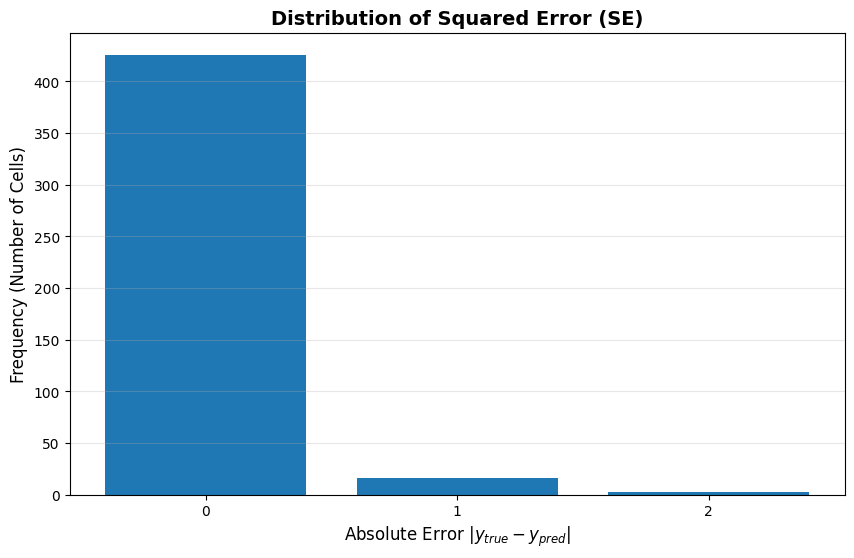

In [7]:
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

preds:dict[str, list[int]] = load_json('data/test/labels.json')
labels:dict[str, list[int]] = load_json('data/test/labels-manual.json')

tp = 0
tn = 0
fp = 0
fn = 0
n_clusters = 0
SE = []
AE = []
for pcluster in preds:
    if pcluster not in labels:
        continue
    n_clusters+= 1
    
    label = labels[pcluster]
    pred = preds[pcluster][0]

    # 1. Add square errors:
    SE += [(i-pred)**2 for i in label]
    AE += [abs(i-pred) for i in label]

    # 2. Add cluster precisions:
    pos = len([i for i in label if i >= 2])
    neg = sum([i for i in label if i == 1])

    if pred >= 2: # positives
        tp += pos
        fp += neg
    else: # negatives
        tn += neg
        fn += pos
n_cells = tp+fp+tn+fn
MSE = sum(SE)/len(SE)
MAE = sum(AE)/len(SE)

cluster_specifity = tn/(tn+fp)
cluster_sensitivity = tp/(tp+fn)
cluster_precision = tp / (tp+ fp)

print(len(labels))
print(f"Total clusters: {n_clusters}. Total cells: {n_cells}")
print(f'Cluster sensitivity: {cluster_sensitivity*100:.2f}%')
print(f'Cluster precision: {cluster_precision*100:.2f}%')
print(f'Cluster specificity: {cluster_specifity*100:.2f}%')
print(f'Cluster errors: MAE {MAE:.2f}, MSE: {MSE:.2f}')

plt.figure(figsize=(10,6))
ns = [int(i) for i in AE]
bins = np.arange(min(ns), max(ns) + 2) - 0.5
plt.hist(AE, bins, rwidth=0.8)
plt.title('Distribution of Squared Error (SE)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Error $|y_{true} - y_{pred}|$', fontsize=12)
plt.ylabel('Frequency (Number of Cells)', fontsize=12)
plt.xticks(np.unique(AE))
plt.grid(axis='y', alpha=0.3)
plt.show()